Import Kaggle Data

In [ ]:
from google.colab import files
files.upload()  # Upload your kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"thelostboy056","key":"827d6d47bedd5171a878483371f1107c"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
 94% 310M/331M [00:00<00:00, 743MB/s]
100% 331M/331M [00:00<00:00, 721MB/s]


In [ ]:
!unzip utkface-new.zip

Streaming output truncated to the last 5000 lines.
  inflating: utkface_aligned_cropped/crop_part1/34_1_0_20170109004755204.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_0_20170111182452832.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_1_20170103230340961.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_1_20170104011329697.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_1_20170104165020320.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_1_20170108230211421.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_2_20170104022134829.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_2_20170104023010725.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_2_20170104172537171.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_2_20170104201443273.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_2_20170104204327

Import modules

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, Dropout, Flatten, Input, MaxPooling2D

Load Dataset

In [ ]:
Base_Dir = "/content/UTKFace/"

In [ ]:
image_path = []
age_label = []
gender_label = []

In [ ]:
for filename in os.listdir(Base_Dir):
  image_p = os.path.join(Base_Dir,filename)
  temp = filename.split('_')
  age = temp[0]
  gender = temp[1]
  image_path.append(image_p)
  age_label.append(age)
  gender_label.append(gender)

In [ ]:
df = pd.DataFrame()
df['image'], df['age'], df['gender'] = image_path, age_label, gender_label
df.sample(5)

,image,age,gender
14969,/content/UTKFace/40_0_0_20170105172617405.jpg....,40,0
8105,/content/UTKFace/18_0_0_20170110232624418.jpg....,18,0
15076,/content/UTKFace/53_0_1_20170116191725055.jpg....,53,0
2623,/content/UTKFace/31_1_1_20170112234727752.jpg....,31,1
15641,/content/UTKFace/24_0_2_20170116172518044.jpg....,24,0


/content/UTKFace/60_0_0_20170104211850356.jpg.chip.jpg


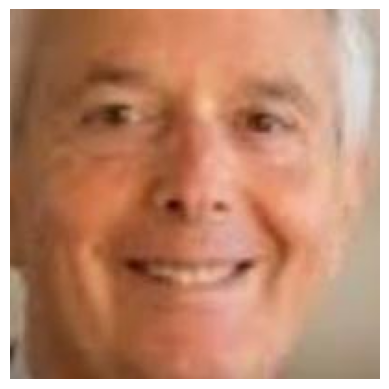

In [ ]:
from PIL import Image
print(df['image'][1])
img = Image.open(df['image'][1])
plt.axis('off')
plt.imshow(img)

In [ ]:
img.size

(200, 200)

<Axes: xlabel='age', ylabel='Density'>

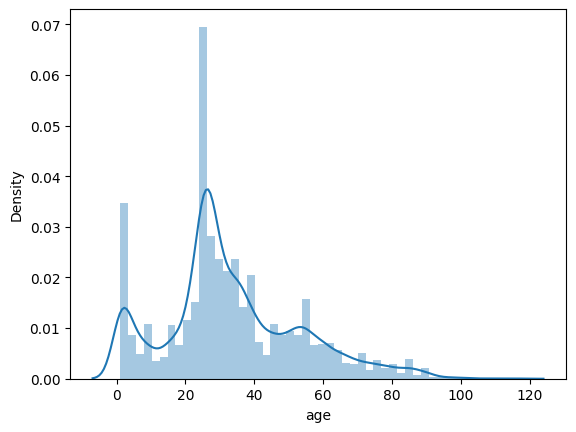

In [ ]:
sns.distplot(df['age'])

<Axes: xlabel='gender', ylabel='count'>

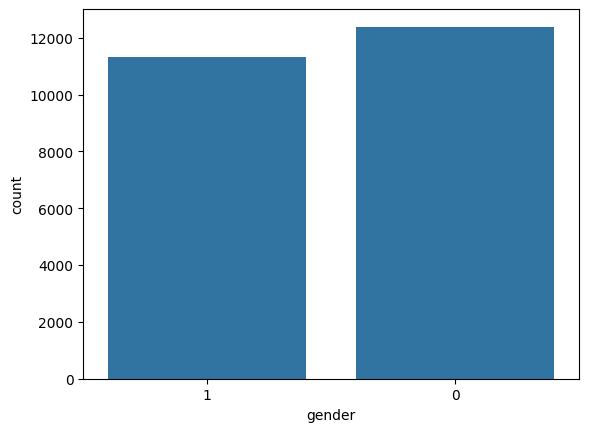

In [ ]:
sns.countplot(data=df,x='gender')

In [ ]:
#Feature Extraction
def feature_extraction(images):
    features = []
    for image in images:
      img = load_img(image, color_mode='grayscale')
      img = img.resize((128,128), Image.Resampling.LANCZOS)
      img = np.array(img)
      features.append(img)

    features = np.array(features)
    features = features.reshape(len(features),128,128,1)
    return features

In [ ]:
img_extracted = feature_extraction(df['image'])

In [ ]:
print(type(img_extracted))
print(img_extracted.shape)
print(img_extracted.dtype)
print(img_extracted[0])

<class 'numpy.ndarray'>
(23708, 128, 128, 1)
uint8
[[[  8]
  [ 10]
  [ 11]
  ...
  [ 37]
  [ 40]
  [ 39]]

 [[  9]
  [ 10]
  [ 13]
  ...
  [ 34]
  [ 37]
  [ 37]]

 [[  9]
  [ 11]
  [ 12]
  ...
  [ 29]
  [ 30]
  [ 32]]

 ...

 [[166]
  [173]
  [179]
  ...
  [ 37]
  [ 40]
  [ 50]]

 [[173]
  [178]
  [183]
  ...
  [ 34]
  [ 38]
  [ 48]]

 [[178]
  [183]
  [186]
  ...
  [ 36]
  [ 41]
  [ 50]]]


In [ ]:
img_extracted.size

388431872

In [ ]:
img_extracted.shape

(23708, 128, 128, 1)

In [ ]:
img_extracted = img_extracted/255.0

In [ ]:
y_gender = np.array(df['gender'], dtype=np.int32)
y_age = np.array(df['age'], dtype=np.float32)

In [ ]:
y_age.size

23708

In [ ]:
input_shape = (128,128,1)

Model Creation

In [ ]:
from pickle import NONE
input = Input((input_shape))
conv1 = Conv2D(32, kernel_size=(3,3), activation='relu') (input)
maxp1 = MaxPooling2D(pool_size=(2,2)) (conv1)
conv2 = Conv2D(64, kernel_size=(3,3), activation='relu') (maxp1)
maxp2 = MaxPooling2D(pool_size=(2,2)) (conv2)
conv3 = Conv2D(128, kernel_size=(3,3), activation='relu') (maxp2)
maxp3 = MaxPooling2D(pool_size=(2,2)) (conv3)
conv4 = Conv2D(256, kernel_size=(3,3), activation='relu') (maxp3)
maxp4 = MaxPooling2D(pool_size=(2,2)) (conv4)
#flattening the last max pool output
flatten = Flatten() (maxp4)

#adding dense layer
dense_num = Dense(256, activation='relu') (flatten)
dense_cat = Dense(256, activation='relu') (flatten)

#adding droupout layers
drop_out1 = Dropout(0.5) (dense_cat)
drop_out2 = Dropout(0.5) (dense_num)

#output layers
output_gen = Dense(1, activation='sigmoid', name='gender_output') (drop_out1)
output_age = Dense(1, activation='relu', name='age_output') (drop_out2)

my_model = Model(inputs=[input],outputs=[output_gen,output_age])

#compiling the model
my_model.compile(loss=['binary_crossentropy','mae'], optimizer='adam', metrics=['accuracy', None])

In [ ]:
my_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 126, 126,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 63, 63,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 30, 30,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 14, 14,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 12, 12,    │    295,168 │ max_pooling2d_6[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 6, 6, 256) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 9216)      │          0 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │  2,359,552 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │  2,359,552 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │        257 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │        257 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,107,458 (19.48 MB)

 Trainable params: 5,107,458 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#training the model
history = my_model.fit(x=img_extracted,y=[y_gender,y_age], batch_size=32, epochs=30, validation_split=0.2)

Epoch 1/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - age_output_loss: 4.4652 - gender_output_accuracy: 0.9402 - gender_output_loss: 0.1351 - loss: 4.6002 - val_age_output_loss: 6.4764 - val_gender_output_accuracy: 0.8937 - val_gender_output_loss: 0.3058 - val_loss: 6.8047
Epoch 2/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - age_output_loss: 4.4968 - gender_output_accuracy: 0.9400 - gender_output_loss: 0.1340 - loss: 4.6308 - val_age_output_loss: 6.7404 - val_gender_output_accuracy: 0.8891 - val_gender_output_loss: 0.3080 - val_loss: 7.0423
Epoch 3/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - age_output_loss: 4.3776 - gender_output_accuracy: 0.9424 - gender_output_loss: 0.1342 - loss: 4.5118 - val_age_output_loss: 6.4208 - val_gender_output_accuracy: 0.8927 - val_gender_output_loss: 0.3201 - val_loss: 6.7422
Epoch 4/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - age_output_loss: 4.3252 - gender_output_accuracy: 0.9407 - gender_output_loss: 0.1322 - loss: 4.4573 - val_age_outpu

In [ ]:
my_model.save('my_model.h5')

In [ ]:
url = '/content/croped_face.jpg'

In [ ]:
img_prediction = feature_extraction([url])

In [ ]:
img_prediction = img_prediction/255.0

In [ ]:
pred = my_model.predict(img_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 899ms/step


In [ ]:
pred

[array([[0.45921224]], dtype=float32), array([[22.423735]], dtype=float32)]